In [1]:
import matplotlib.pyplot as plt
import numpy as np  
import pandas as pd
from collections import Counter
import matplotlib.dates as mdates
from matplotlib.animation import FuncAnimation 
import random
from itertools import count

## **What I Need Cleaned:**

### **Priority Issues:**

1. **Standardize Customer_Email**
   - Remove invalid emails (missing @, wrong domains)
   - Flag suspicious ones

2. **Fix Product_Purchased**
   - "iPhone 13" vs "iphone13" vs "Iphone 13" → should be same
   - Create master list of 10-15 products

3. **Clean Ticket_Description**
   - Remove HTML tags
   - Standardize line breaks
   - Extract key phrases

4. **Handle Missing Values**
   - Customer_Satisfaction (30% missing)
   - Resolution (25% missing)
   - Agent_Name (15% missing)

5. **Fix Time Fields**
   - Negative First_Response_Time → make positive
   - Cap outliers (tickets open for months)
   - Standardize to hours

6. **Deduplicate**
   - Check for duplicate Ticket_ID
   - Check for same customer + same issue

---

## **Your Deliverables:**

### **1. Cleaned CSV File**
- All issues addressed
- Add these new columns:
  - `Response_Time_Category` (Fast: <1h, Normal: 1-24h, Slow: >24h)
  - `Issue_Complexity` (Simple/Complex based on resolution time)
  - `Customer_History` (New/Returning customer)

### **2. Documentation**
Write a brief report including:
- What you fixed (with examples)
- How you handled missing values
- Any assumptions you made
- Data you couldn't clean (and why)

### **3. Summary Statistics**
After cleaning, tell me:
- Top 5 most common issues
- Average resolution time by priority
- Customer satisfaction by product
- Which team has best resolution rate?

---

## **Bonus Points If You:**

- Create a **data quality report** showing "before vs after"
- Identify **anomalies** (suspicious patterns)
- Suggest **3 business insights** from the clean data

---


**When you're done, share:**
1. Your cleaned CSV
2. Your Python code
3. Your summary report

In [2]:
data = pd.read_csv('data.csv')
data.head()

,Responder_id,LanguagesWorkedWith
0,1,HTML/CSS;Java;JavaScript;Python
1,2,C++;HTML/CSS;Python
2,3,HTML/CSS
3,4,C;C++;C#;Python;SQL
4,5,C++;HTML/CSS;Java;JavaScript;Python;SQL;VBA


In [3]:
id = data['Responder_id']
lang = data['LanguagesWorkedWith']
print(id)
print(lang)

0            1
1            2
2            3
3            4
4            5
         ...  
87564    88182
87565    88212
87566    88282
87567    88377
87568    88863
Name: Responder_id, Length: 87569, dtype: int64
0                          HTML/CSS;Java;JavaScript;Python
1                                      C++;HTML/CSS;Python
2                                                 HTML/CSS
3                                      C;C++;C#;Python;SQL
4              C++;HTML/CSS;Java;JavaScript;Python;SQL;VBA
                               ...                        
87564                             HTML/CSS;Java;JavaScript
87565                           HTML/CSS;JavaScript;Python
87566    Bash/Shell/PowerShell;Go;HTML/CSS;JavaScript;W...
87567                        HTML/CSS;JavaScript;Other(s):
87568    Bash/Shell/PowerShell;HTML/CSS;Java;JavaScript...
Name: LanguagesWorkedWith, Length: 87569, dtype: str


In [4]:
lang_counter = Counter()

for response in lang:
    lang_counter.update(response.split(';'))

In [5]:
languages = []
popularity = []

for item in lang_counter.items():
    languages.append(item[0])
    popularity.append(item[1])

print(languages)
print(popularity)

['HTML/CSS', 'Java', 'JavaScript', 'Python', 'C++', 'C', 'C#', 'SQL', 'VBA', 'R', 'Bash/Shell/PowerShell', 'Ruby', 'Rust', 'TypeScript', 'WebAssembly', 'Other(s):', 'Go', 'PHP', 'Assembly', 'Kotlin', 'Swift', 'Objective-C', 'Elixir', 'Erlang', 'Clojure', 'F#', 'Scala', 'Dart']
[55466, 35917, 59219, 36443, 20524, 18017, 27097, 47544, 4781, 5048, 31991, 7331, 2794, 18523, 1015, 7920, 7201, 23030, 5833, 5620, 5744, 4191, 1260, 777, 1254, 973, 3309, 1683]


In [6]:
print(lang_counter)

Counter({'JavaScript': 59219, 'HTML/CSS': 55466, 'SQL': 47544, 'Python': 36443, 'Java': 35917, 'Bash/Shell/PowerShell': 31991, 'C#': 27097, 'PHP': 23030, 'C++': 20524, 'TypeScript': 18523, 'C': 18017, 'Other(s):': 7920, 'Ruby': 7331, 'Go': 7201, 'Assembly': 5833, 'Swift': 5744, 'Kotlin': 5620, 'R': 5048, 'VBA': 4781, 'Objective-C': 4191, 'Scala': 3309, 'Rust': 2794, 'Dart': 1683, 'Elixir': 1260, 'Clojure': 1254, 'WebAssembly': 1015, 'F#': 973, 'Erlang': 777})


In [7]:
print(lang_counter.most_common(10))

[('JavaScript', 59219), ('HTML/CSS', 55466), ('SQL', 47544), ('Python', 36443), ('Java', 35917), ('Bash/Shell/PowerShell', 31991), ('C#', 27097), ('PHP', 23030), ('C++', 20524), ('TypeScript', 18523)]


In [8]:
print(lang_counter.items())

dict_items([('HTML/CSS', 55466), ('Java', 35917), ('JavaScript', 59219), ('Python', 36443), ('C++', 20524), ('C', 18017), ('C#', 27097), ('SQL', 47544), ('VBA', 4781), ('R', 5048), ('Bash/Shell/PowerShell', 31991), ('Ruby', 7331), ('Rust', 2794), ('TypeScript', 18523), ('WebAssembly', 1015), ('Other(s):', 7920), ('Go', 7201), ('PHP', 23030), ('Assembly', 5833), ('Kotlin', 5620), ('Swift', 5744), ('Objective-C', 4191), ('Elixir', 1260), ('Erlang', 777), ('Clojure', 1254), ('F#', 973), ('Scala', 3309), ('Dart', 1683)])


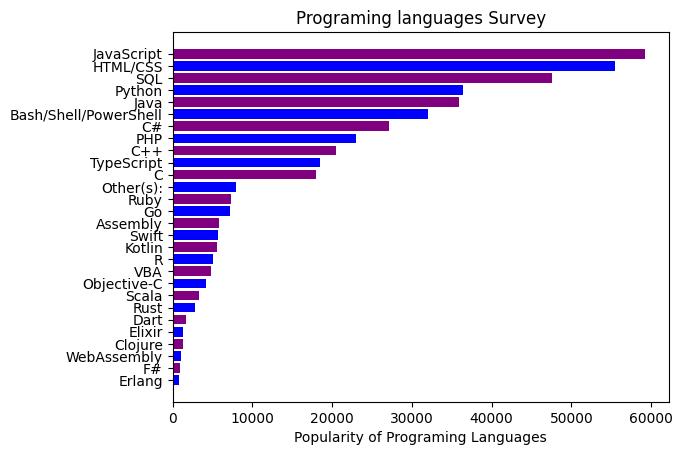

In [9]:
sorted_pairs = sorted(zip(popularity, languages))
popularity_sorted, languages_sorted = zip(*sorted_pairs)
colors = ['blue' if i % 2 == 0 else 'purple' for i in range(len(languages_sorted))]
plt.barh(languages_sorted, popularity_sorted, color=colors)
plt.xlabel('Popularity of Programing Languages')
plt.title('Programing languages Survey')
plt.show()

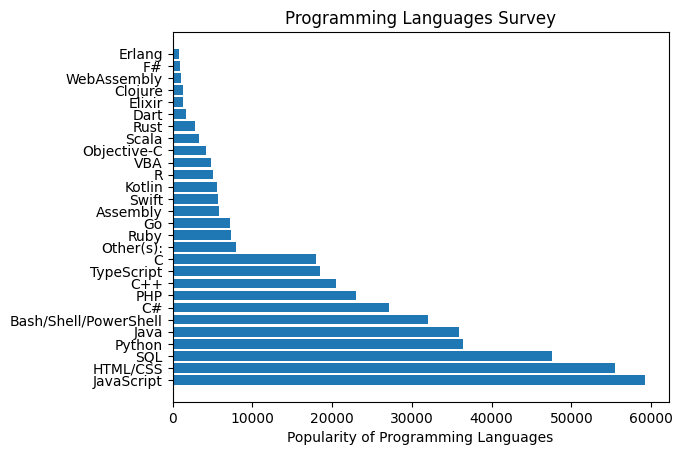

In [10]:
# Combine languages and popularity into pairs and sort by popularity (descending)
sorted_pairs = sorted(zip(popularity, languages), reverse=True)
popularity_sorted, languages_sorted = zip(*sorted_pairs)

plt.barh(languages_sorted, popularity_sorted)
plt.xlabel('Popularity of Programming Languages')
plt.title('Programming Languages Survey')
plt.show()

In [11]:
data = pd.read_csv('AAPL.csv')
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600


In [12]:
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

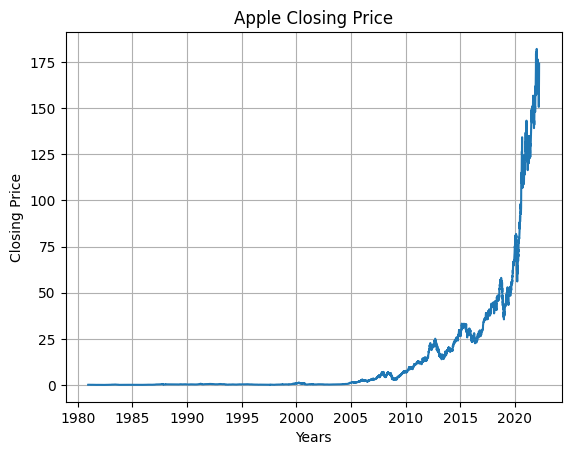

In [13]:
plt.plot(data['Date'], data['Close'])
plt.xlabel('Years')
plt.ylabel('Closing Price')
plt.title('Apple Closing Price')
plt.grid(True)
plt.show()

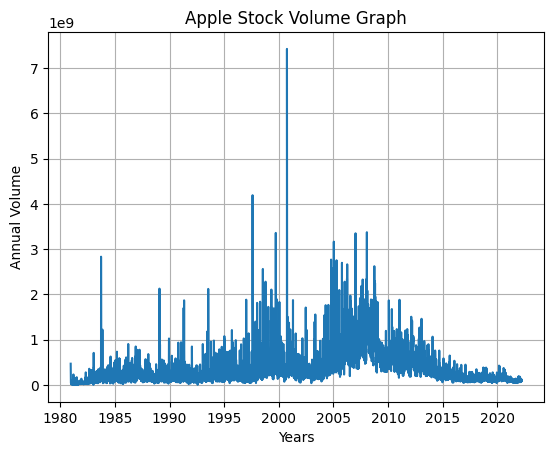

In [14]:
plt.plot(data['Date'], data['Volume'])
plt.xlabel('Years')
plt.ylabel('Annual Volume')
plt.title('Apple Stock Volume Graph')
plt.grid(True)
plt.show()

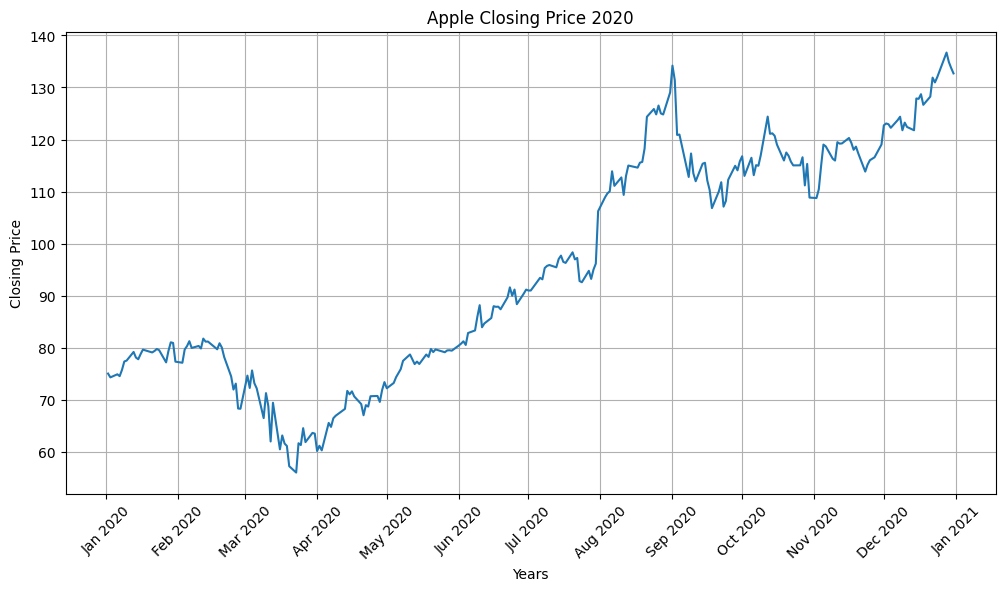

In [15]:
data20 = data[(data['Date'] >= '2020-01-01') & (data['Date'] <= '2020-12-31')]
plt.figure(figsize=(12, 6))
plt.plot(data20['Date'], data20['Close'])
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Every 1 months
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # "Jan 2023"
plt.xlabel('Years')
plt.ylabel('Closing Price')
plt.title('Apple Closing Price 2020')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [16]:
data

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600
...,...,...,...,...,...,...,...
10404,2022-03-18,160.509995,164.479996,159.759995,163.979996,163.979996,123351200
10405,2022-03-21,163.509995,166.350006,163.009995,165.380005,165.380005,95811400
10406,2022-03-22,165.509995,169.419998,164.910004,168.820007,168.820007,81532000
10407,2022-03-23,167.990005,172.639999,167.649994,170.210007,170.210007,98062700


In [17]:
yearly_avg = data.groupby(data['Date'].dt.year)['Close'].mean()
yearly_avg.head()

Date
1980    0.135903
1981    0.108548
1982    0.085459
1983    0.167274
1984    0.119651
Name: Close, dtype: float64

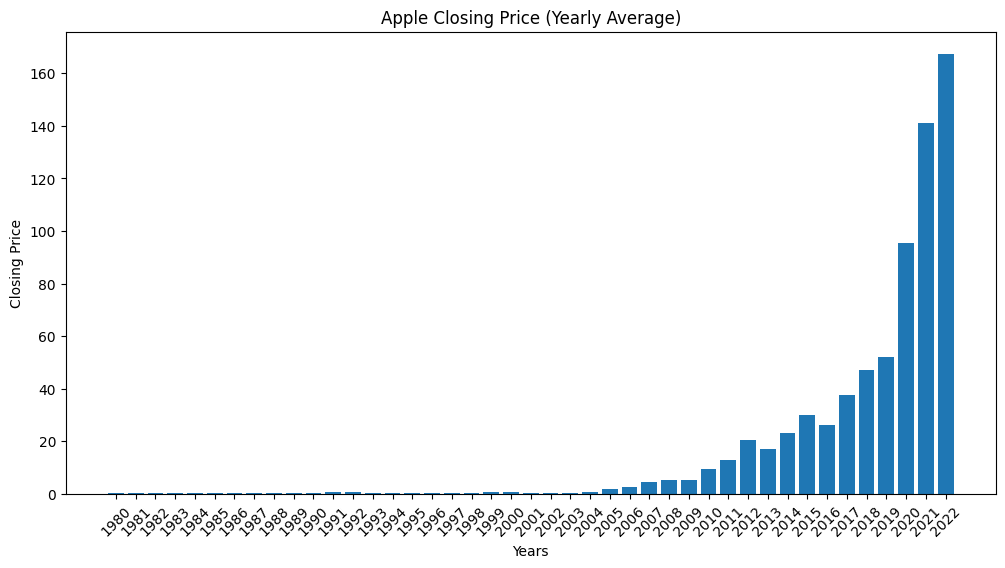

In [18]:
plt.figure(figsize=(12, 6))
plt.bar(yearly_avg.index, yearly_avg.values)
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))  # Every 1 year
plt.xlabel('Years')
plt.ylabel('Closing Price')
plt.title('Apple Closing Price (Yearly Average)')
plt.xticks(yearly_avg.index, rotation=45)
plt.show()

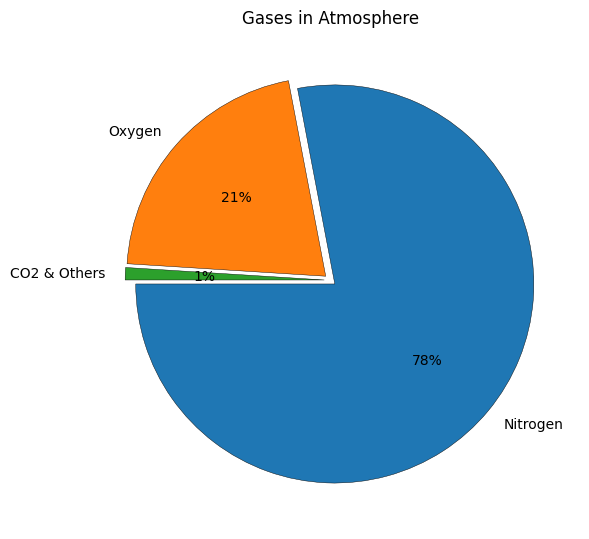

In [19]:
slices = [78, 21, 1]
labels = ['Nitrogen', 'Oxygen', 'CO2 & Others']
plt.style.use('seaborn-v0_8-notebook')
plt.title("Gases in Atmosphere")
plt.pie(slices, labels= labels,explode=(0.03, 0.03, 0.03),startangle= 180, wedgeprops= {'edgecolor' :'black'}, autopct='%1.0f%%')
plt.tight_layout()
plt.show()

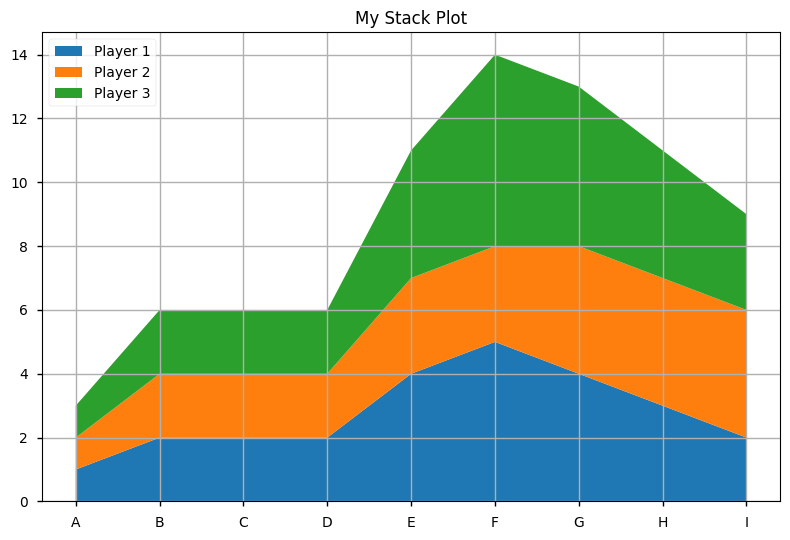

In [20]:
minutes = ['A','B','C',"D",'E','F','G','H','I']
player_1 = [1,2,2,2,4,5,4,3,2]
player_2 = [1,2,2,2,3,3,4,4,4]
player_3 = [1,2,2,2,4,6,5,4,3]
labels_1 = ['Player 1', 'Player 2', 'Player 3']
plt.stackplot(minutes, player_1, player_2, player_3, labels= labels_1)
plt.title('My Stack Plot')
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

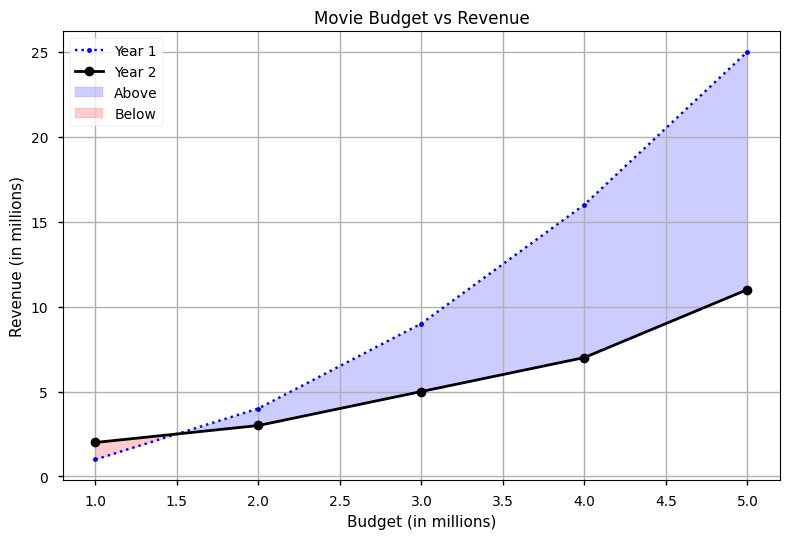

In [21]:
budget_x = [1, 2, 3, 4, 5]
revenue_y1 = np.array([1, 4, 9, 16, 25])
revenue_y2 = np.array([2, 3, 5, 7, 11])
plt.plot(budget_x, revenue_y1, 'b.:', label='Year 1')  
plt.plot(budget_x, revenue_y2, color="k", linewidth=2, marker="o", label='Year 2')
plt.fill_between(budget_x, revenue_y1, revenue_y2,where= (revenue_y1 >= revenue_y2), interpolate=True,color='blue', alpha=0.2, label = 'Above')
plt.fill_between(budget_x, revenue_y1, revenue_y2,where= (revenue_y1 < revenue_y2),interpolate=True,color='red', alpha=0.2, label = 'Below')
plt.title('Movie Budget vs Revenue')
plt.xlabel('Budget (in millions)')
plt.ylabel('Revenue (in millions)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
age_data = pd.read_csv('age data.csv')
age_data.head()

,Responder_id,Age
0,1,14
1,2,19
2,3,28
3,4,22
4,5,30


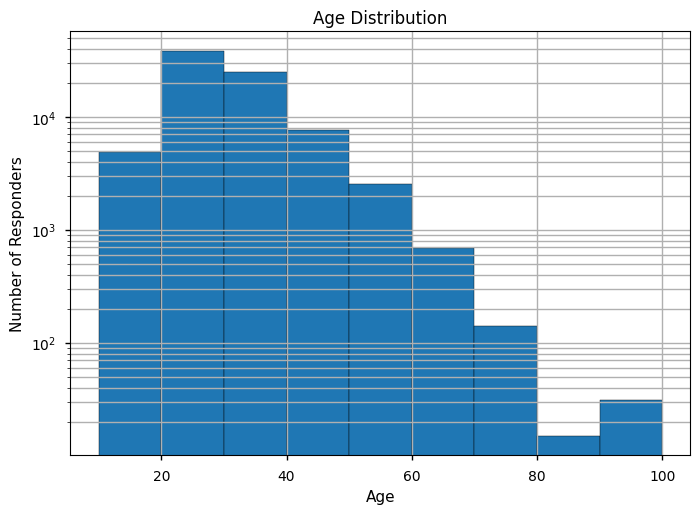

In [23]:
age_data = pd.read_csv('age data.csv')
id = age_data['Responder_id']
age = age_data['Age']
plt.hist(age, bins= [10,20,30,40,50,60,70,80,90,100], edgecolor= 'black', log=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Responders')
plt.grid(True, which='both')
plt.show()

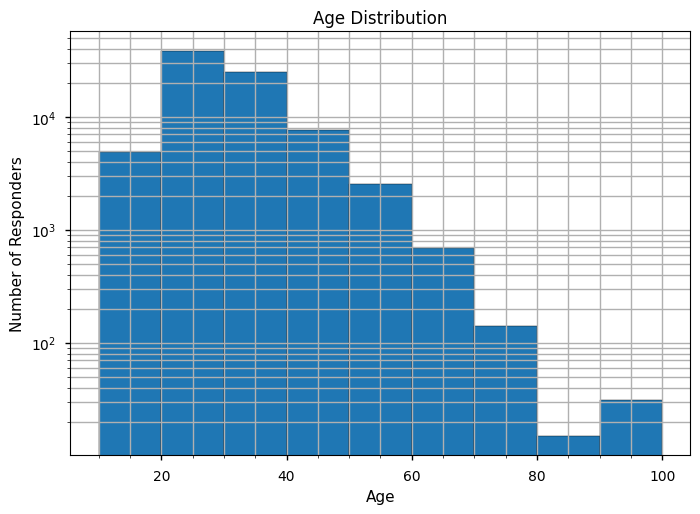

In [24]:
age_data = pd.read_csv('age data.csv')
id = age_data['Responder_id']
age = age_data['Age']
plt.hist(age, bins=[10,20,30,40,50,60,70,80,90,100], edgecolor='black', log=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Responders')
plt.minorticks_on()  # Show minor ticks
plt.grid(True, which='both')
plt.show()

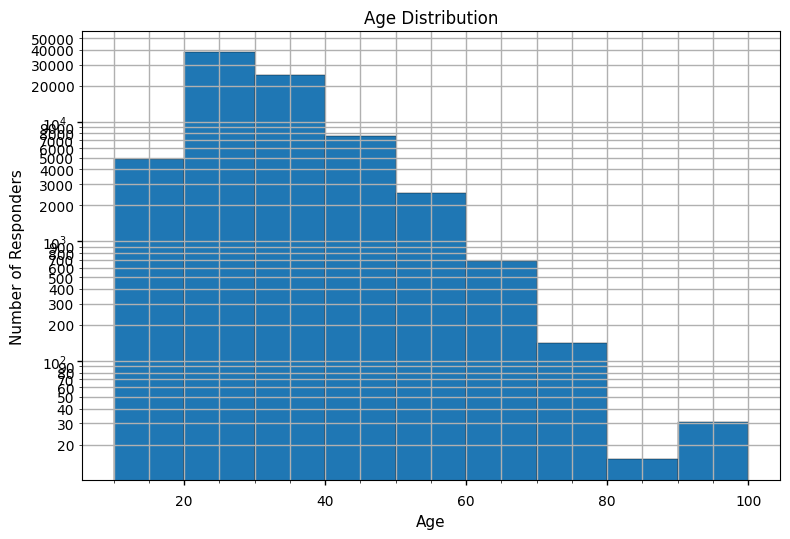

In [25]:
import matplotlib.ticker as ticker  # Add this import

age_data = pd.read_csv('age data.csv')
id = age_data['Responder_id']
age = age_data['Age']
plt.hist(age, bins=[10,20,30,40,50,60,70,80,90,100], edgecolor='black', log=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Responders')

plt.minorticks_on()  # Show minor ticks

# Set minor locator for y-axis (log scale, so use LogLocator)
plt.gca().yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10)*.1, numticks=100))
plt.gca().yaxis.set_minor_formatter(ticker.ScalarFormatter())  # Show minor tick labels

plt.grid(True, which='both')
plt.tight_layout()
plt.show()


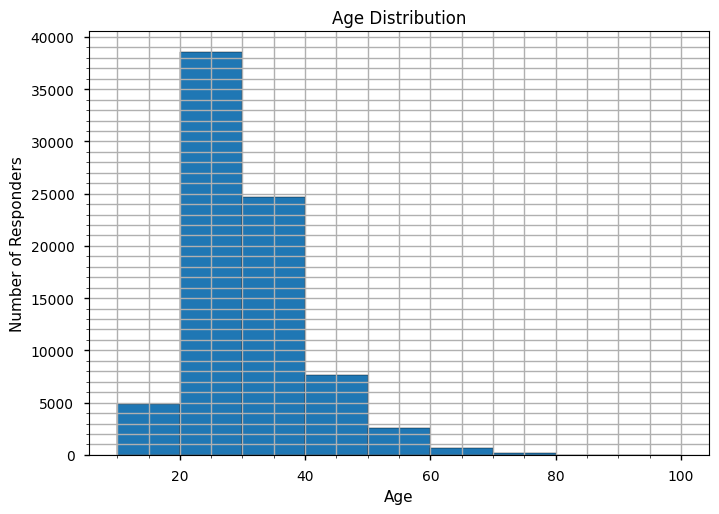

In [26]:
age_data = pd.read_csv('age data.csv')
id = age_data['Responder_id']
age = age_data['Age']
plt.hist(age, bins= [10,20,30,40,50,60,70,80,90,100], edgecolor= 'black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Responders')
plt.minorticks_on()
plt.grid(True, which='both')
plt.show()

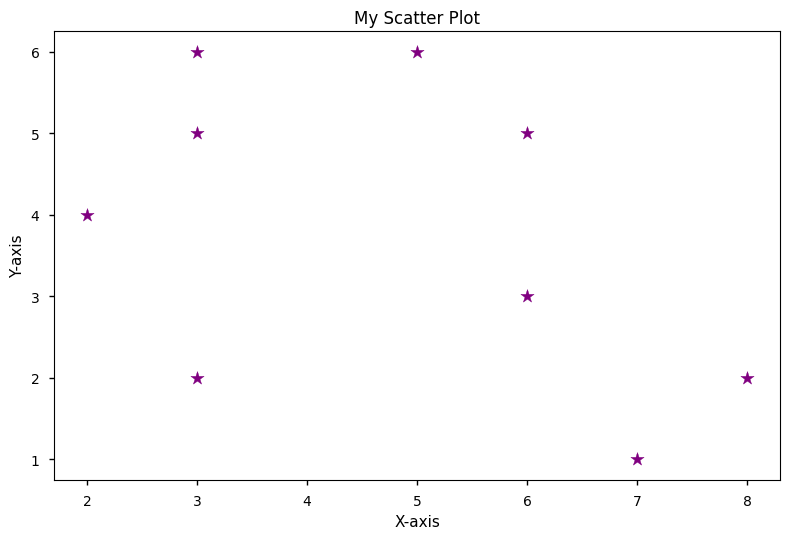

In [27]:
x = [3,6,2,6,5,8,3,7,3]
y = [2,5,4,3,6,2,5,1,6]
plt.scatter(x, y, marker='*', color='purple', s=100)
plt.title('My Scatter Plot')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.tight_layout()
plt.show()

In [28]:

vid_data.head()

NameError: name 'vid_data' is not defined

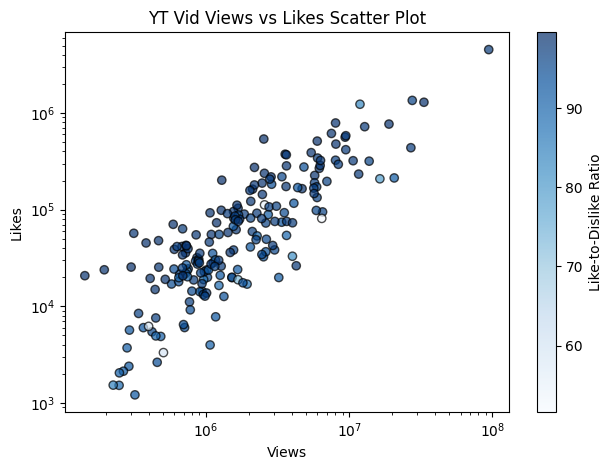

In [ ]:
vid_data = pd.read_csv('2019-05-31-data.csv')
views = vid_data['view_count']
likes = vid_data['likes']
ratio =vid_data['ratio']
plt.scatter(views, likes, c=ratio, cmap='Blues',edgecolors= 'black', linewidths=1, alpha=0.7) # viridis, plasma, inferno, magma, cividis ,summer, Reds, Blues
plt.colorbar(label='Like-to-Dislike Ratio')
plt.xscale('log')
plt.yscale('log')   
plt.xlabel('Views')
plt.ylabel('Likes')
plt.title('YT Vid Views vs Likes Scatter Plot')
plt.tight_layout()
plt.show()

In [ ]:
data = pd.read_csv('AAPL.csv')
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600


In [ ]:
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

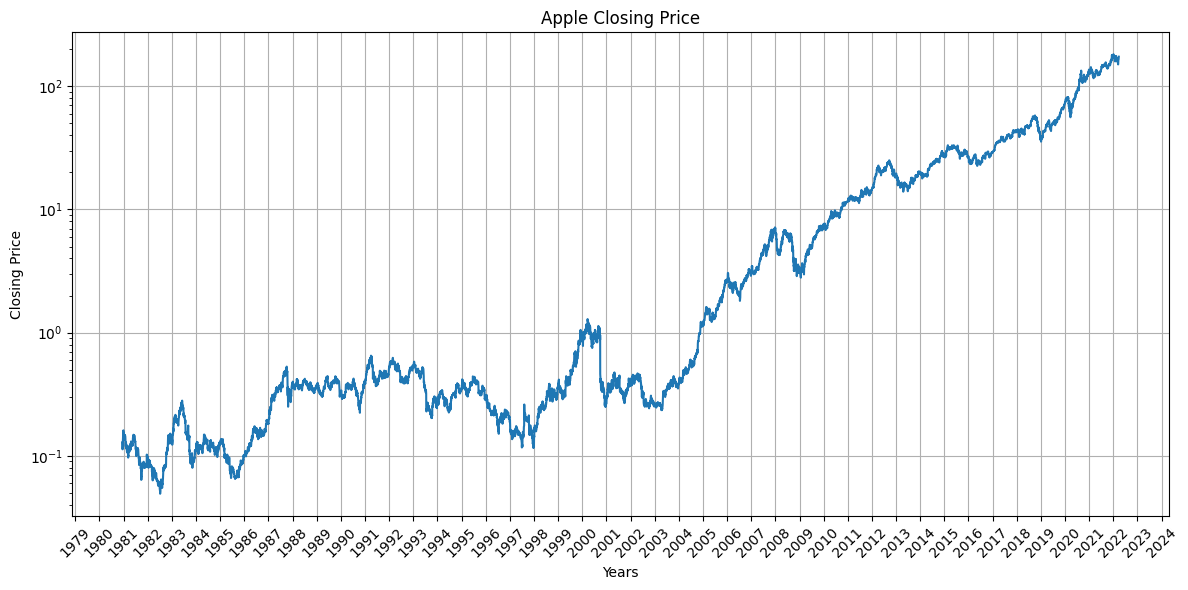

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Close'])
plt.xlabel('Years')
plt.ylabel('Closing Price')
plt.title('Apple Closing Price')
plt.yscale('log')
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))  # Every 1 year
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # "
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
x_val = []
y_val = []
index = count()

def animate(i):
    x_val.append(next(index))
    y_val.append(random.randint(0,5))
    plt.cla()
    plt.plot(x_val, y_val)

ani = FuncAnimation(plt.gcf(), animate, interval=1000, cache_frame_data=False)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
dt = pd.read_csv('customer_support_tickets.csv')
dt.head(2)

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN


In [3]:
dt.shape

(8469, 17)

In [4]:
dt.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

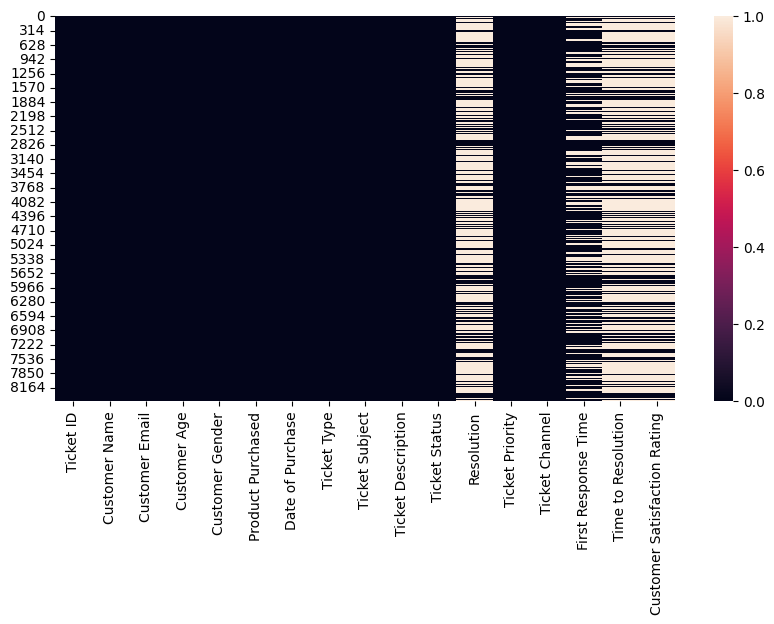

In [5]:
plt.figure(figsize=(10, 5))
sns.heatmap(dt.isnull())
plt.show()

In [6]:
dt.columns.duplicated().sum()

np.int64(0)

In [7]:
# Series of counts, one entry per column
dup_counts = dt.apply(lambda col: col.duplicated().sum())
print(dup_counts)

Ticket ID                          0
Customer Name                    441
Customer Email                   149
Customer Age                    8416
Customer Gender                 8466
Product Purchased               8427
Date of Purchase                7739
Ticket Type                     8464
Ticket Subject                  8453
Ticket Description               392
Ticket Status                   8466
Resolution                      5699
Ticket Priority                 8465
Ticket Channel                  8465
First Response Time             2998
Time to Resolution              5740
Customer Satisfaction Rating    8463
dtype: int64


In [8]:
dt.dtypes

Ticket ID                         int64
Customer Name                       str
Customer Email                      str
Customer Age                      int64
Customer Gender                     str
Product Purchased                   str
Date of Purchase                    str
Ticket Type                         str
Ticket Subject                      str
Ticket Description                  str
Ticket Status                       str
Resolution                          str
Ticket Priority                     str
Ticket Channel                      str
First Response Time                 str
Time to Resolution                  str
Customer Satisfaction Rating    float64
dtype: object

In [9]:
dt['Date of Purchase'] = pd.to_datetime(dt['Date of Purchase'])

In [10]:
dt['Product Purchased'].unique()

<StringArray>
[                    'GoPro Hero',                    'LG Smart TV',
                       'Dell XPS',               'Microsoft Office',
               'Autodesk AutoCAD',              'Microsoft Surface',
             'Philips Hue Lights',        'Fitbit Versa Smartwatch',
           'Dyson Vacuum Cleaner',                'Nintendo Switch',
      'Microsoft Xbox Controller', 'Nintendo Switch Pro Controller',
                'Nest Thermostat',               'Sony PlayStation',
            'GoPro Action Camera',                           'Xbox',
             'LG Washing Machine',                      'Canon EOS',
                    'HP Pavilion',                  'Amazon Kindle',
                'Lenovo ThinkPad',                  'Fitbit Charge',
                'Adobe Photoshop',                   'Google Pixel',
                    'Amazon Echo',                    'PlayStation',
                 'Samsung Galaxy',                         'iPhone',
                    

In [11]:
dt.shape

(8469, 17)

In [12]:
dt['Product Purchased'].duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8464     True
8465     True
8466     True
8467     True
8468     True
Name: Product Purchased, Length: 8469, dtype: bool

In [14]:
dt

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Category
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,Camera
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,TV
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,Laptop
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,Software
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,Software
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN,Other
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN,Other
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0,Other
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0,Other


In [20]:
dt['Category'].value_counts()

Category
Gaming        1158
Laptop        1131
Camera        1061
Smart Home     865
Smartphone     826
Audio          788
TV             642
Appliance      622
Watch          601
Software       577
E-reader       198
Name: count, dtype: int64

In [16]:
dt.groupby('Category')

In [17]:
dt['Category'] = dt['Product Purchased'].map({
    # Smartphones
    'Google Pixel': 'Smartphone',
    'Samsung Galaxy': 'Smartphone',
    'iPhone': 'Smartphone',
    'Sony Xperia': 'Smartphone',
    
    # TVs
    'LG Smart TV': 'TV',
    'LG OLED': 'TV',
    'Sony 4K HDR TV': 'TV',
    
    # Watches/Fitness Trackers
    'Fitbit Versa Smartwatch': 'Watch',
    'Fitbit Charge': 'Watch',
    'Garmin Forerunner': 'Watch',
    
    # Laptops/Computers
    'Dell XPS': 'Laptop',
    'Microsoft Surface': 'Laptop',
    'HP Pavilion': 'Laptop',
    'Lenovo ThinkPad': 'Laptop',
    'MacBook Pro': 'Laptop',
    'Asus ROG': 'Laptop',
    
    # Cameras
    'GoPro Hero': 'Camera',
    'GoPro Action Camera': 'Camera',
    'Canon EOS': 'Camera',
    'Canon DSLR Camera': 'Camera',
    'Nikon D': 'Camera',
    
    # Gaming Consoles/Controllers
    'Nintendo Switch': 'Gaming',
    'Microsoft Xbox Controller': 'Gaming',
    'Nintendo Switch Pro Controller': 'Gaming',
    'Sony PlayStation': 'Gaming',
    'Xbox': 'Gaming',
    'PlayStation': 'Gaming',
    
    # Smart Home/IoT
    'Philips Hue Lights': 'Smart Home',
    'Nest Thermostat': 'Smart Home',
    'Amazon Echo': 'Smart Home',
    'Google Nest': 'Smart Home',
    
    # Audio
    'Apple AirPods': 'Audio',
    'Bose QuietComfort': 'Audio',
    'Samsung Soundbar': 'Audio',
    'Bose SoundLink Speaker': 'Audio',
    
    # Software
    'Microsoft Office': 'Software',
    'Autodesk AutoCAD': 'Software',
    'Adobe Photoshop': 'Software',
    
    # Appliances
    'Dyson Vacuum Cleaner': 'Appliance',
    'LG Washing Machine': 'Appliance',
    'Roomba Robot Vacuum': 'Appliance',
    
    # E-readers
    'Amazon Kindle': 'E-reader'
})

In [18]:
dt['Customer Satisfaction Rating'].value_counts()

Customer Satisfaction Rating
3.0    580
1.0    553
2.0    549
5.0    544
4.0    543
Name: count, dtype: int64

In [21]:
dupe_rows = (dt
             .groupby(['Customer Name','Customer Email'])
             .filter(lambda grp: len(grp) > 1))

In [22]:
dupe_rows

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Category


In [23]:
!pip install email-validator pandas


   ---------------------------------------- 0/3 [idna]
   ---------------------------------------- 0/3 [idna]
   ---------------------------------------- 0/3 [idna]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspy

In [27]:
from email_validator import validate_email, EmailNotValidError

# Assuming your emails are in a column named 'Customer Email'
emails = dt['Customer Email'].tolist()

# Check each email directly
valid_emails = []
invalid_emails = []

for email in emails:
    try:
        # Set check_deliverability=False to skip domain/MX validation
        valid = validate_email(email, check_deliverability=False)
        valid_emails.append(valid.email)  # normalized email
    except EmailNotValidError as e:
        invalid_emails.append((email, str(e)))

print(f"Valid emails: {len(valid_emails)}")
print(f"Invalid emails: {len(invalid_emails)}")

Valid emails: 8469
Invalid emails: 0


In [25]:
dt['Customer Email'].tolist()

['carrollallison@example.com',
 'clarkeashley@example.com',
 'gonzalestracy@example.com',
 'bradleyolson@example.org',
 'bradleymark@example.com',
 'sheenasmith@example.com',
 'donaldkeith@example.org',
 'joelwilliams@example.com',
 'joshua24@example.com',
 'clopez@example.com',
 'mbrown@example.org',
 'davisjohn@example.net',
 'jensenwilliam@example.net',
 'gwendolyn51@example.net',
 'medinasteven@example.net',
 'amy41@example.net',
 'watkinsbarbara@example.com',
 'mooredeborah@example.org',
 'brenda20@example.net',
 'jameslopez@example.com',
 'rogermcgrath@example.net',
 'zbond@example.net',
 'ljohnson@example.org',
 'carlsonmatthew@example.org',
 'lbarron@example.org',
 'johnstonbeth@example.com',
 'pmercado@example.org',
 'jeffersonmichael@example.net',
 'garciastacy@example.com',
 'shericase@example.net',
 'jessicahenderson@example.net',
 'zstewart@example.org',
 'greenkeith@example.net',
 'darlenelee@example.org',
 'fernandezmark@example.org',
 'jessica10@example.org',
 'katherin

In [ ]:
import pandas as pd
import re
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from collections import Counter

# Download required NLTK data (run once)
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('averaged_perceptron_tagger')

class TicketCleaner:
    def __init__(self, text):
        self.original_text = text
        self.cleaned_text = text
        self.key_phrases = []
        
    def remove_html_tags(self):
        """Remove HTML tags from text"""
        if pd.isna(self.cleaned_text):
            return self
        # Using BeautifulSoup
        soup = BeautifulSoup(str(self.cleaned_text), 'html.parser')
        self.cleaned_text = soup.get_text(separator=' ')
        return self
    
    def standardize_line_breaks(self):
        """Standardize line breaks and whitespace"""
        if pd.isna(self.cleaned_text):
            return self
        
        # Replace various line breaks with \n
        self.cleaned_text = re.sub(r'\r\n|\r|\n', '\n', self.cleaned_text)
        
        # Remove multiple consecutive line breaks
        self.cleaned_text = re.sub(r'\n\s*\n', '\n\n', self.cleaned_text)
        
        # Remove multiple spaces
        self.cleaned_text = re.sub(r' +', ' ', self.cleaned_text)
        
        # Trim whitespace
        self.cleaned_text = self.cleaned_text.strip()
        
        return self
    
    def extract_key_phrases(self, top_n=10):
        """Extract key phrases using NLTK"""
        if pd.isna(self.cleaned_text) or self.cleaned_text == '':
            return self
        
        # Tokenize sentences
        try:
            sentences = sent_tokenize(self.cleaned_text)
            
            # Get stopwords
            stop_words = set(stopwords.words('english'))
            
            # Add custom stopwords for tickets
            custom_stopwords = {'please', 'thank', 'thanks', 'regards', 'dear', 'hi', 'hello', 
                              'would', 'could', 'help', 'need', 'issue', 'problem'}
            stop_words.update(custom_stopwords)
            
            # Extract noun phrases (simple approach)
            all_words = []
            for sentence in sentences:
                words = word_tokenize(sentence.lower())
                # Get POS tags
                pos_tags = nltk.pos_tag(words)
                
                # Extract nouns and adjectives (potential key phrases)
                for word, pos in pos_tags:
                    if word.isalpha() and word not in stop_words and len(word) > 2:
                        if pos.startswith('NN') or pos.startswith('JJ'):  # Noun or Adjective
                            all_words.append(word)
            
            # Count frequencies
            word_freq = Counter(all_words)
            
            # Get top phrases (single words for simplicity)
            self.key_phrases = [word for word, count in word_freq.most_common(top_n)]
            
        except Exception as e:
            print(f"Error in key phrase extraction: {e}")
            self.key_phrases = []
        
        return self
    
    def clean_all(self, extract_phrases=True):
        """Perform all cleaning steps"""
        self.remove_html_tags()
        self.standardize_line_breaks()
        if extract_phrases:
            self.extract_key_phrases()
        return self

# ============================================
# HOW TO USE WITH YOUR DATAFRAME
# ============================================

# Your dataframe is named 'dt' with column 'Ticket Description'
# dt = pd.read_csv('your_file.csv')  # or however you loaded it

def clean_ticket_descriptions(df, text_column='Ticket Description'):
    """
    Clean all ticket descriptions in your dataframe
    
    Args:
        df: your pandas DataFrame (named 'dt')
        text_column: name of column containing ticket descriptions (default: 'Ticket Description')
    
    Returns:
        DataFrame with new columns for cleaned text and key phrases
    """
    
    # Create new columns
    df['Cleaned_Description'] = ''
    df['Key_Phrases'] = ''
    
    total_tickets = len(df)
    print(f"Processing {total_tickets} tickets...")
    
    for idx, text in enumerate(df[text_column]):
        if pd.isna(text):
            df.at[idx, 'Cleaned_Description'] = ''
            df.at[idx, 'Key_Phrases'] = ''
        else:
            cleaner = TicketCleaner(text)
            cleaner.clean_all(extract_phrases=True)
            
            df.at[idx, 'Cleaned_Description'] = cleaner.cleaned_text
            df.at[idx, 'Key_Phrases'] = ', '.join(cleaner.key_phrases[:5]) if cleaner.key_phrases else ''
        
        # Print progress every 100 tickets
        if (idx + 1) % 100 == 0:
            print(f"Processed {idx + 1}/{total_tickets} tickets")
    
    print("Done! All tickets processed.")
    return df

# ============================================
# ACTUAL USAGE - JUST RUN THESE LINES
# ============================================

# 1. First, make a backup of your original data (optional but recommended)
dt_original = dt.copy()

# 2. Clean your ticket descriptions
dt = clean_ticket_descriptions(dt, 'Ticket Description')

# 3. View the results
print("\nFirst 5 rows after cleaning:")
print(dt[['Ticket Description', 'Cleaned_Description', 'Key_Phrases']].head())

# 4. Check which tickets have key phrases
print("\nTickets with extracted key phrases:")
print(dt[dt['Key_Phrases'] != ''][['Ticket Description', 'Key_Phrases']].head(10))

# 5. Save the cleaned data (optional)
# dt.to_csv('cleaned_tickets.csv', index=False)

In [33]:
import re
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from collections import Counter

# Download required NLTK data (run once)
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('averaged_perceptron_tagger')

class TicketCleaner:
    def __init__(self, text):
        self.original_text = text
        self.cleaned_text = text
        self.key_phrases = []
        
    def remove_html_tags(self):
        """Remove HTML tags from text"""
        if pd.isna(self.cleaned_text):
            return self
        # Using BeautifulSoup
        soup = BeautifulSoup(str(self.cleaned_text), 'html.parser')
        self.cleaned_text = soup.get_text(separator=' ')
        return self
    
    def standardize_line_breaks(self):
        """Standardize line breaks and whitespace"""
        if pd.isna(self.cleaned_text):
            return self
        
        # Replace various line breaks with \n
        self.cleaned_text = re.sub(r'\r\n|\r|\n', '\n', self.cleaned_text)
        
        # Remove multiple consecutive line breaks
        self.cleaned_text = re.sub(r'\n\s*\n', '\n\n', self.cleaned_text)
        
        # Remove multiple spaces
        self.cleaned_text = re.sub(r' +', ' ', self.cleaned_text)
        
        # Trim whitespace
        self.cleaned_text = self.cleaned_text.strip()
        
        return self
    
    def extract_key_phrases(self, top_n=10):
        """Extract key phrases using NLTK"""
        if pd.isna(self.cleaned_text) or self.cleaned_text == '':
            return self
        
        # Tokenize sentences
        try:
            sentences = sent_tokenize(self.cleaned_text)
            
            # Get stopwords
            stop_words = set(stopwords.words('english'))
            
            # Add custom stopwords for tickets
            custom_stopwords = {'please', 'thank', 'thanks', 'regards', 'dear', 'hi', 'hello', 
                              'would', 'could', 'help', 'need', 'issue', 'problem'}
            stop_words.update(custom_stopwords)
            
            # Extract noun phrases (simple approach)
            all_words = []
            for sentence in sentences:
                words = word_tokenize(sentence.lower())
                # Get POS tags
                pos_tags = nltk.pos_tag(words)
                
                # Extract nouns and adjectives (potential key phrases)
                for word, pos in pos_tags:
                    if word.isalpha() and word not in stop_words and len(word) > 2:
                        if pos.startswith('NN') or pos.startswith('JJ'):  # Noun or Adjective
                            all_words.append(word)
            
            # Count frequencies
            word_freq = Counter(all_words)
            
            # Get top phrases (single words for simplicity)
            self.key_phrases = [word for word, count in word_freq.most_common(top_n)]
            
        except Exception as e:
            print(f"Error in key phrase extraction: {e}")
            self.key_phrases = []
        
        return self
    
    def clean_all(self, extract_phrases=True):
        """Perform all cleaning steps"""
        self.remove_html_tags()
        self.standardize_line_breaks()
        if extract_phrases:
            self.extract_key_phrases()
        return self

In [34]:
def clean_ticket_descriptions(df, text_column='Ticket Description'):
    """
    Clean all ticket descriptions in your dataframe
    
    Args:
        df: your pandas DataFrame (named 'dt')
        text_column: name of column containing ticket descriptions (default: 'Ticket Description')
    
    Returns:
        DataFrame with new columns for cleaned text and key phrases
    """
    
    # Create new columns
    df['Cleaned_Description'] = ''
    df['Key_Phrases'] = ''
    
    total_tickets = len(df)
    print(f"Processing {total_tickets} tickets...")
    
    for idx, text in enumerate(df[text_column]):
        if pd.isna(text):
            df.at[idx, 'Cleaned_Description'] = ''
            df.at[idx, 'Key_Phrases'] = ''
        else:
            cleaner = TicketCleaner(text)
            cleaner.clean_all(extract_phrases=True)
            
            df.at[idx, 'Cleaned_Description'] = cleaner.cleaned_text
            df.at[idx, 'Key_Phrases'] = ', '.join(cleaner.key_phrases[:5]) if cleaner.key_phrases else ''
        
        # Print progress every 100 tickets
        if (idx + 1) % 100 == 0:
            print(f"Processed {idx + 1}/{total_tickets} tickets")
    
    print("Done! All tickets processed.")
    return df

In [41]:
# 2. Clean your ticket descriptions
dt = clean_ticket_descriptions(dt, 'Ticket Description')

# 3. View the results
print("\nFirst 5 rows after cleaning:")
print(dt[['Ticket Description', 'Cleaned_Description', 'Key_Phrases']].head())

Processing 8469 tickets...
Processed 100/8469 tickets
Processed 200/8469 tickets
Processed 300/8469 tickets
Processed 400/8469 tickets
Processed 500/8469 tickets
Processed 600/8469 tickets
Processed 700/8469 tickets
Processed 800/8469 tickets
Processed 900/8469 tickets
Processed 1000/8469 tickets
Processed 1100/8469 tickets
Processed 1200/8469 tickets
Processed 1300/8469 tickets
Processed 1400/8469 tickets
Processed 1500/8469 tickets
Processed 1600/8469 tickets
Processed 1700/8469 tickets
Processed 1800/8469 tickets
Processed 1900/8469 tickets
Processed 2000/8469 tickets
Processed 2100/8469 tickets
Processed 2200/8469 tickets
Processed 2300/8469 tickets
Processed 2400/8469 tickets
Processed 2500/8469 tickets
Processed 2600/8469 tickets
Processed 2700/8469 tickets
Processed 2800/8469 tickets
Processed 2900/8469 tickets
Processed 3000/8469 tickets
Processed 3100/8469 tickets
Processed 3200/8469 tickets
Processed 3300/8469 tickets
Processed 3400/8469 tickets
Processed 3500/8469 tickets
Pr

In [42]:
# 4. Check which tickets have key phrases
print("\nTickets with extracted key phrases:")
print(dt[dt['Key_Phrases'] != ''][['Ticket Description', 'Key_Phrases']].head(10))


Tickets with extracted key phrases:
                                  Ticket Description  \
0  I'm having an issue with the {product_purchase...   
1  I'm having an issue with the {product_purchase...   
2  I'm facing a problem with my {product_purchase...   
3  I'm having an issue with the {product_purchase...   
4  I'm having an issue with the {product_purchase...   
5  I'm facing a problem with my {product_purchase...   
6  I'm unable to access my {product_purchased} ac...   
7  I'm having an issue with the {product_purchase...   
8  I'm having an issue with the {product_purchase...   
9  My {product_purchased} is making strange noise...   

                                        Key_Phrases  
0               address, assist, billing, zip, code  
1        assist, product, intermittent, fine, times  
2                fine, yesterday, original, charger  
3   assist, interested, feedback, customer, support  
4           game, assist, note, seller, responsible  
5         fine, yester

In [36]:
# Download required NLTK data (run once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package punkt to C:\Users\Mazhar
[nltk_data]     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\Mazhar
[nltk_data]     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Mazhar Iqbal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.


True

In [38]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\Mazhar
[nltk_data]     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [40]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Mazhar Iqbal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [30]:
!pip install beautifulsoup4


   ---------------------------------------- 0/2 [soupsieve]
   -------------------- ------------------- 1/2 [beautifulsoup4]
   -------------------- ------------------- 1/2 [beautifulsoup4]
   -------------------- ------------------- 1/2 [beautifulsoup4]
   -------------------- ------------------- 1/2 [beautifulsoup4]
   ---------------------------------------- 2/2 [beautifulsoup4]



In [32]:
!pip install nltk

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ ------------------------

In [ ]:
dt[['Cleaned_Description','Ticket Description']]. .head(1)

,Cleaned_Description,Ticket Description
0,I'm having an issue with the {product_purchase...,I'm having an issue with the {product_purchase...


In [46]:
# Quick view with full content
pd.set_option('display.max_colwidth', None)
dt[['Ticket Description', 'Cleaned_Description']].head(3)

,Ticket Description,Cleaned_Description
0,"I'm having an issue with the {product_purchased}. Please assist.\n\nYour billing zip code is: 71701.\n\nWe appreciate that you have requested a website address.\n\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.","I'm having an issue with the {product_purchased}. Please assist.\n\nYour billing zip code is: 71701.\n\nWe appreciate that you have requested a website address.\n\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists."
1,"I'm having an issue with the {product_purchased}. Please assist.\n\nIf you need to change an existing product.\n\nI'm having an issue with the {product_purchased}. Please assist.\n\nIf The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.","I'm having an issue with the {product_purchased}. Please assist.\n\nIf you need to change an existing product.\n\nI'm having an issue with the {product_purchased}. Please assist.\n\nIf The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly."
2,"I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.\n\n1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly.","I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.\n\n1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly."


In [47]:
# Find rows where Ticket Description != Cleaned_Description
different_rows = dt[dt['Ticket Description'] != dt['Cleaned_Description']]

print(f"Found {len(different_rows)} rows where descriptions are different")
print("\nThese rows have been cleaned/modified:")
print(different_rows[['Ticket Description', 'Cleaned_Description']])

Found 794 rows where descriptions are different

These rows have been cleaned/modified:
                                                                                                                                                                                                                                                                                                                                            Ticket Description  \
4             I'm having an issue with the {product_purchased}. Please assist.\n\n\nNote: The seller is not responsible for any damages arising out of the delivery of the battleground game. Please have the game in good condition and shipped to you I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.   
14                                                                I'm having an issue with the {product_purchased}. Please assist.\n\nProduct Name: TPUBASK3E3KQ0\n\n\nJoin Date: Oct 2007 Posts: 11,532\n\n

In [50]:
different_rows[['Ticket Description', 'Cleaned_Description']].head(10)

,Ticket Description,Cleaned_Description
4,I'm having an issue with the {product_purchased}. Please assist.\n\n\nNote: The seller is not responsible for any damages arising out of the delivery of the battleground game. Please have the game in good condition and shipped to you I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.,I'm having an issue with the {product_purchased}. Please assist.\n\nNote: The seller is not responsible for any damages arising out of the delivery of the battleground game. Please have the game in good condition and shipped to you I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.
14,"I'm having an issue with the {product_purchased}. Please assist.\n\nProduct Name: TPUBASK3E3KQ0\n\n\nJoin Date: Oct 2007 Posts: 11,532\n\nQuote: I've recently updated the firmware of my {product_purchased}, and the issue started happening afterward. Could it be related to the update?","I'm having an issue with the {product_purchased}. Please assist.\n\nProduct Name: TPUBASK3E3KQ0\n\nJoin Date: Oct 2007 Posts: 11,532\n\nQuote: I've recently updated the firmware of my {product_purchased}, and the issue started happening afterward. Could it be related to the update?"
15,"I'm having an issue with the {product_purchased}. Please assist.\n\n\nPlease note, you might have already paid for this product, which means spectators are not buying any of the products from the sale as their donations will go straight I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.","I'm having an issue with the {product_purchased}. Please assist.\n\nPlease note, you might have already paid for this product, which means spectators are not buying any of the products from the sale as their donations will go straight I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer."
47,"I'm having an issue with the {product_purchased}. Please assist.\n\n\nThis product is not found on, and should NOT come from, this site.\n\n\nNot sure about what this product covers?\n\nProduct Description I'm experiencing this issue on multiple devices of the same model, so it seems to be a widespread problem.","I'm having an issue with the {product_purchased}. Please assist.\n\nThis product is not found on, and should NOT come from, this site.\n\nNot sure about what this product covers?\n\nProduct Description I'm experiencing this issue on multiple devices of the same model, so it seems to be a widespread problem."
73,My {product_purchased} is making strange noises and not functioning properly. I suspect there might be a hardware issue. Can you please help me with this?\n\n\nThis is a product that must fit in a box. Please let me I've noticed a peculiar error message popping up on my {product_purchased} screen. It says '{error_message}'. What does it mean?,My {product_purchased} is making strange noises and not functioning properly. I suspect there might be a hardware issue. Can you please help me with this?\n\nThis is a product that must fit in a box. Please let me I've noticed a peculiar error message popping up on my {product_purchased} screen. It says '{error_message}'. What does it mean?
82,"I'm having an issue with the {product_purchased}. Please assist.\n\n<p>\n\nA full time customer service representative will arrive soon.\n\n<p>\n\nIf you would like to respond to a message I've tried different settings and configurations on my {product_purchased}, but the issue persists.","I'm having an issue with the {product_purchased}. Please assist.\n\nA full time customer service representative will arrive soon.\n\nIf you would like to respond to a message I've tried different settings and configurations on my {product_purchased}, but the issue persists."
91,"I'm having an issue with the {product_purchased}. Please assist.\n\n\n(Beware when I accidentally add a link to your product and th

In [49]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

# Count how many rows are truly different
diff_count = (dt['Ticket Description'] != dt['Cleaned_Description']).sum()
total_count = len(dt)

print(f"Total rows: {total_count}")
print(f"Rows with differences: {diff_count}")
print(f"Rows that are identical: {total_count - diff_count}")

if diff_count == 0:
    print("\n⚠️  WARNING: No differences found! The cleaning function didn't modify any text.")

Total rows: 8469
Rows with differences: 794
Rows that are identical: 7675


In [67]:
pd.reset_option('display.max_colwidth')

In [72]:
dt.head(10)

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,...,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Category,Cleaned_Description,Key_Phrases,Satisfaction Rating and Resolution Originally Missing due to Open Ticket
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,...,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,Camera,I'm having an issue with the {product_purchase...,"address, assist, billing, zip, code",False
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,...,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,TV,I'm having an issue with the {product_purchase...,"assist, product, intermittent, fine, times",False
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,...,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,Laptop,I'm facing a problem with my {product_purchase...,"fine, yesterday, original, charger",False
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,...,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,Software,I'm having an issue with the {product_purchase...,"assist, interested, feedback, customer, support",False
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,...,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,Software,I'm having an issue with the {product_purchase...,"game, assist, note, seller, responsible",False
5,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...,...,NaN,Low,Social media,NaN,NaN,0.0,Software,I'm facing a problem with my {product_purchase...,"fine, yesterday, new, available, software",False
6,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...,...,NaN,Critical,Social media,NaN,NaN,0.0,Laptop,I'm unable to access my {product_purchased} ac...,"unable, access, account, credentials, error",False
7,8,Denise Lee,joelwilliams@example.com,23,Male,Philips Hue Lights,2020-08-09,Refund request,Battery life,I'm having an issue with the {product_purchase...,...,NaN,Critical,Social media,NaN,NaN,0.0,Smart Home,I'm having an issue with the {product_purchase...,"assist, suppliers, confirm, try, inventory",False
8,9,Nicolas Wilson,joshua24@example.com,60,Other,Fitbit Versa Smartwatch,2020-07-16,Technical issue,Installation support,I'm having an issue with the {product_purchase...,...,NaN,Low,Social media,2023-06-01 10:32:47,NaN,NaN,Watch,I'm having an issue with the {product_purchase...,"exact, assist, type, method, different",False
9,10,William Dawson,clopez@example.com,27,Male,Dyson Vacuum Cleaner,2020-03-06,Refund request,Payment issue,My {product_purchased} is making strange noise...,...,NaN,Critical,Phone,2023-06-01 09:25:48,NaN,NaN,Appliance,My {product_purchased} is making strange noise...,"strange, noises, hardware, request, intermittent",False


In [71]:
dt['Satisfaction Rating and Resolution Originally Missing due to Open Ticket'].value_counts()

Satisfaction Rating and Resolution Originally Missing due to Open Ticket
False    8469
Name: count, dtype: int64

In [69]:
# Step 1: Create flag columns for transparency
dt['Satisfaction Rating and Resolution Originally Missing due to Open Ticket'] = (dt['Ticket Status'] == 'Open') & (dt['Customer Satisfaction Rating'].isnull()) & (dt['Time to Resolution'].isnull())

In [ ]:
# Step 2: Handle Open tickets - use 0 to indicate "Not Applicable"
dt.loc[dt['Ticket Status'] == 'Open', 'Customer Satisfaction Rating'] = 0.0
dt.loc[dt['Ticket Status'] == 'Open', 'Time to Resolution'] = 0.0


TypeError: Invalid value '0.0' for dtype 'str'. Value should be a string or missing value, got 'float' instead.

In [54]:
dt.isna().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
Category                           0
Cleaned_Description                0
Key_Phrases                        0
dtype: int64

In [55]:
dt['Ticket Status'].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

In [ ]:
dt[dt['Ticket Status'] == 'Open']['Customer Satisfaction Rating'].unique()

array([nan])

In [74]:
pd.DataFrame(dt).to_csv('cleaned1_customer_support_tickets.csv', index=False)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## **What I Need Cleaned:**

### **Priority Issues:**

1. **Standardize Customer_Email**
   - Remove invalid emails (missing @, wrong domains)
   - Flag suspicious ones

2. **Fix Product_Purchased**
   - "iPhone 13" vs "iphone13" vs "Iphone 13" → should be same
   - Create master list of 10-15 products

3. **Clean Ticket_Description**
   - Remove HTML tags
   - Standardize line breaks
   - Extract key phrases

4. **Handle Missing Values**
   - Customer_Satisfaction (30% missing)
   - Resolution (25% missing)
   - Agent_Name (15% missing)

5. **Fix Time Fields**
   - Negative First_Response_Time → make positive
   - Cap outliers (tickets open for months)
   - Standardize to hours

6. **Deduplicate**
   - Check for duplicate Ticket_ID
   - Check for same customer + same issue

---

## **Your Deliverables:**

### **1. Cleaned CSV File**
- All issues addressed
- Add these new columns:
  - `Response_Time_Category` (Fast: <1h, Normal: 1-24h, Slow: >24h)
  - `Issue_Complexity` (Simple/Complex based on resolution time)
  - `Customer_History` (New/Returning customer)

### **2. Documentation**
Write a brief report including:
- What you fixed (with examples)
- How you handled missing values
- Any assumptions you made
- Data you couldn't clean (and why)

### **3. Summary Statistics**
After cleaning, tell me:
- Top 5 most common issues
- Average resolution time by priority
- Customer satisfaction by product
- Which team has best resolution rate?

---

## **Bonus Points If You:**

- Create a **data quality report** showing "before vs after"
- Identify **anomalies** (suspicious patterns)
- Suggest **3 business insights** from the clean data

---


**When you're done, share:**
1. Your cleaned CSV
2. Your Python code
3. Your summary report

In [35]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Category,Cleaned_Description,Key_Phrases
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,Critical,Social media,2023-06-01 12:15:36,NaT,0.0,Camera,I'm having an issue with the {product_purchase...,"address, assist, billing, zip, code"
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,Critical,Chat,2023-06-01 16:45:38,NaT,0.0,TV,I'm having an issue with the {product_purchase...,"assist, product, intermittent, fine, times"
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,Laptop,I'm facing a problem with my {product_purchase...,"fine, yesterday, original, charger"
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,Software,I'm having an issue with the {product_purchase...,"assist, interested, feedback, customer, support"
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,Software,I'm having an issue with the {product_purchase...,"game, assist, note, seller, responsible"


In [7]:
df.drop(columns=['Satisfaction Rating and Resolution Originally Missing due to Open Ticket'], inplace=True)

In [5]:
df['Ticket Status'].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

In [38]:
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])

In [20]:
df['Customer Satisfaction Rating'].mean()

np.float64(1.4822834645669292)

In [19]:
df.shape

(8469, 19)

In [12]:
df['First Response Time'].median()

Timestamp('2023-06-01 11:26:25')

In [13]:
df['First Response Time'].mode()

0   2023-06-01 01:21:19
1   2023-06-01 15:21:42
2   2023-06-01 20:45:39
Name: First Response Time, dtype: datetime64[us]

In [16]:
df['First Response Time'].value_counts()

First Response Time
2023-06-01 01:21:19    3
2023-06-01 15:21:42    3
2023-06-01 20:45:39    3
2023-06-01 17:46:49    2
2023-06-01 12:05:51    2
                      ..
2023-06-01 14:15:07    1
2023-06-01 17:26:11    1
2023-06-02 00:36:18    1
2023-06-01 09:44:22    1
2023-06-01 18:28:24    1
Name: count, Length: 5470, dtype: int64

In [31]:
df['Customer Satisfaction Rating'] = df['Customer Satisfaction Rating'].fillna(0)

In [26]:
df['Time to Resolution'] = df['Time to Resolution'].fillna(pd.NaT)

In [39]:
df.dtypes

Ticket ID                                int64
Customer Name                              str
Customer Email                             str
Customer Age                             int64
Customer Gender                            str
Product Purchased                          str
Date of Purchase                datetime64[us]
Ticket Type                                str
Ticket Subject                             str
Ticket Description                         str
Ticket Status                              str
Ticket Priority                            str
Ticket Channel                             str
First Response Time             datetime64[us]
Time to Resolution              datetime64[us]
Customer Satisfaction Rating           float64
Category                                   str
Cleaned_Description                        str
Key_Phrases                                str
dtype: object

In [33]:
df['Customer Satisfaction Rating'] = df['Customer Satisfaction Rating'].map({0: 0.0, 1.0: 1.0, 2.0: 2.0, 3.0: 3.0, 4.0: 4.0, 5.0: 5.0})

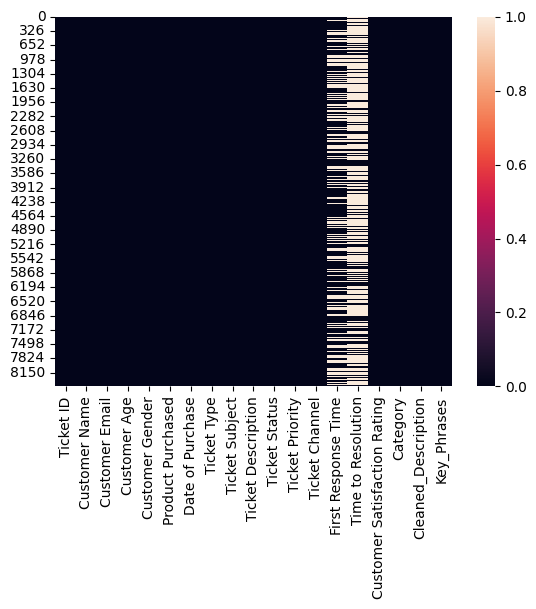

In [36]:
sns.heatmap(df.isnull())
plt.show()

In [43]:
df.to_csv('cleaned2_customer_support_tickets.csv', index=False)

In [42]:
df.drop(columns=['Ticket Description'], inplace=True)

In [44]:
df['Customer Age'].value_counts()

Customer Age
52    186
56    182
27    180
24    180
34    177
59    177
44    173
20    173
48    172
63    171
33    171
46    171
42    170
19    169
69    169
67    168
53    168
65    167
54    166
51    165
29    165
55    164
18    163
30    163
21    162
60    161
58    159
45    159
62    158
38    157
37    156
61    156
70    156
50    155
41    153
43    153
32    152
26    152
35    150
49    149
40    148
39    147
57    147
25    147
28    146
22    146
23    145
36    145
68    144
64    141
66    140
31    138
47    137
Name: count, dtype: int64

In [49]:
df['Customer Gender'].value_counts()

Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64